# NILM — BiLSTM Seq-to-Seq Pipeline (Event Extraction)

## Architecture

```
Input : (B, MAX_LEN, 5)   — 5-channel aggregate event pattern
  Ch 0: Raw aggregate (normalised)
  Ch 1: Autocorrelation of aggregate
  Ch 2: Cross-correlation vs appliance ON profile
  Ch 3: sin(hour)
  Ch 4: cos(hour)
         ↓
BiLSTM layer 1  hidden=128, bidirectional  → (B, MAX_LEN, 256)
         ↓
BiLSTM layer 2  hidden=64,  bidirectional  → (B, MAX_LEN, 128)
         ↓
Linear(128→64) → ReLU → Dropout → Linear(64→1) → Sigmoid
         ↓
Output: (B, MAX_LEN)  — full appliance power sequence
```

## Key differences from Seq-to-Point
- **Input**: event patterns with leading/trailing zeros — not sliding windows
- **Output**: full appliance sequence — not a single midpoint scalar
- **Loss**: masked MSE — only penalises non-padded positions
- **Evaluation**: per-timestep F1 and MAE over entire event
- **Threshold**: 50W converted to normalised space per appliance

## 0 · Imports

In [74]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.7.0+cu128
CUDA    : True
Device  : cuda
GPU     : NVIDIA GeForce RTX 5080 Laptop GPU


## 1 · Load Datasets & Configuration

In [75]:
NILM_DIR           = 'nilm_datasets'
N_CHANNELS         = 7
WATTS_ON_THRESHOLD = 50.0

# Load normalisation caps
norm_caps = pd.read_csv(
    os.path.join(NILM_DIR, 'norm_caps.csv')
).iloc[0].to_dict()

# Load max_lens per appliance
max_lens = pd.read_csv(
    os.path.join(NILM_DIR, 'max_lens.csv')
).iloc[0].to_dict()
max_lens = {k: int(v) for k, v in max_lens.items()}

# Compute 50W threshold in normalised space per appliance
norm_thresholds = {}
for app, cap in norm_caps.items():
    if app != 'Whole-House Meter' and cap > 0:
        norm_thresholds[app] = float(
            np.clip(WATTS_ON_THRESHOLD / cap, 0.0, 1.0)
        )

print('Norm caps (W):')
for k, v in norm_caps.items():
    thr = norm_thresholds.get(k, None)
    thr_str = f'  thr_norm={thr:.4f}' if thr else ''
    print(f'  {k:<25}: {v:>8.1f} W{thr_str}')

print('\nMax pattern lengths (minutes):')
for k, v in max_lens.items():
    print(f'  {k:<25}: {v}')

Norm caps (W):
  Whole-House Meter        :   5369.0 W
  Clothes Dryer            :   5005.6 W  thr_norm=0.0100
  Clothes Washer           :    907.0 W  thr_norm=0.0551
  Dishwasher               :    823.0 W  thr_norm=0.0608
  Kitchen Fridge           :    445.0 W  thr_norm=0.1124
  Heat Pump                :   2484.0 W  thr_norm=0.0201

Max pattern lengths (minutes):
  Clothes Dryer            : 143
  Clothes Washer           : 46
  Dishwasher               : 107
  Kitchen Fridge           : 373
  Heat Pump                : 503


In [76]:
balanced_datasets = {}

# Find available appliances from directory names
appliances = sorted([
    d.replace('_', ' ')
    for d in os.listdir(NILM_DIR)
    if os.path.isdir(os.path.join(NILM_DIR, d))
    and d != '__pycache__'
])

print(f'{"Appliance":<20} {"MAX_LEN":>8} {"Train":>8} '
      f'{"Val":>6} {"Test":>6} {"Shape":>15}')
print('-' * 70)

for app in appliances:
    safe    = app.replace(' ', '_').replace('/', '-')
    app_dir = os.path.join(NILM_DIR, safe)

    if app not in max_lens:
        print(f'  {app}: no max_len — skipping')
        continue

    max_len = max_lens[app]
    splits  = {}
    ok      = True

    for split in ['train', 'val', 'test']:
        x_path = os.path.join(app_dir, f'X_{split}.npy')
        y_path = os.path.join(app_dir, f'y_{split}.npy')
        m_path = os.path.join(app_dir, f'mask_{split}.npy')

        if not os.path.exists(x_path):
            # Create empty arrays if split missing
            splits[f'X_{split}']    = np.zeros((0, max_len, N_CHANNELS), np.float32)
            splits[f'y_{split}']    = np.zeros((0, max_len), np.float32)
            splits[f'mask_{split}'] = np.zeros((0, max_len), np.float32)
            continue

        splits[f'X_{split}']    = np.load(x_path)
        splits[f'y_{split}']    = np.load(y_path)
        splits[f'mask_{split}'] = np.load(m_path)

    splits['max_len'] = max_len
    balanced_datasets[app] = splits

    print(f'{app:<20} {max_len:>8} '
          f'{len(splits["X_train"]):>8} '
          f'{len(splits["X_val"]):>6} '
          f'{len(splits["X_test"]):>6} '
          f'{str(splits["X_train"].shape):>15}')

print(f'\n{len(balanced_datasets)} appliances loaded.')

Appliance             MAX_LEN    Train    Val   Test           Shape
----------------------------------------------------------------------
Clothes Dryer             143      361     18     78   (361, 143, 7)
Clothes Washer             46      563     30    120    (563, 46, 7)
Dishwasher                107      496     32    108   (496, 107, 7)
Heat Pump                 503     1685    117    420  (1685, 503, 7)
Kitchen Fridge            373    23348   1383   4019 (23348, 373, 7)

5 appliances loaded.


## 2 · Dataset & DataLoader

In [77]:
class NILMEventDataset(Dataset):
    """
    X    : (N, max_len, 5)  — 5-channel aggregate event patterns
    y    : (N, max_len)     — appliance power sequences (targets)
    mask : (N, max_len)     — 1=real data, 0=padding
    """
    def __init__(self, X: np.ndarray, y: np.ndarray, mask: np.ndarray):
        assert X.ndim == 3,    f'X must be 3D, got {X.ndim}D'
        assert y.ndim == 2,    f'y must be 2D, got {y.ndim}D'
        assert mask.ndim == 2, f'mask must be 2D, got {mask.ndim}D'
        self.X    = torch.from_numpy(X)
        self.y    = torch.from_numpy(y)
        self.mask = torch.from_numpy(mask)

    def __len__(self):  return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.mask[idx]


def make_loaders(d, batch_size=32, num_workers=0):
    """
    Smaller batch size than before — each sample is now a full event
    sequence (up to MAX_LEN steps), not a single point.
    """
    kw = dict(num_workers=num_workers, pin_memory=False)

    def make_loader(split, shuffle, drop_last):
        X    = d[f'X_{split}']
        y    = d[f'y_{split}']
        mask = d[f'mask_{split}']
        if len(X) == 0:
            return None
        ds = NILMEventDataset(X, y, mask)
        return DataLoader(ds, batch_size=batch_size,
                          shuffle=shuffle, drop_last=drop_last, **kw)

    train_loader = make_loader('train', shuffle=True,  drop_last=True)
    val_loader   = make_loader('val',   shuffle=False, drop_last=False)
    test_loader  = make_loader('test',  shuffle=False, drop_last=False)

    return train_loader, val_loader, test_loader


print('NILMEventDataset and make_loaders defined.')

NILMEventDataset and make_loaders defined.


## 3 · Model — BiLSTM Seq-to-Seq

Two bidirectional LSTM layers process the full event sequence.
At every time step the model predicts the appliance power level.
This is Seq-to-Seq — output shape matches input sequence length.

In [78]:
class BiLSTM_S2S(nn.Module):
    """
    Bidirectional 2-layer LSTM Seq-to-Seq NILM model.

    Input : (B, T, 5)   — batch, max_len, channels
    Output: (B, T)      — predicted appliance power at every time step
    """
    def __init__(self, n_channels=5, hidden1=128, hidden2=64, dropout=0.3):
        super().__init__()

        # Layer 1: processes raw 5-channel input
        self.lstm1 = nn.LSTM(
            input_size  = n_channels,
            hidden_size = hidden1,
            num_layers  = 1,
            batch_first = True,
            bidirectional = True,
        )
        self.drop1 = nn.Dropout(dropout)

        # Layer 2: integrates patterns from layer 1
        self.lstm2 = nn.LSTM(
            input_size  = hidden1 * 2,  # bidirectional output
            hidden_size = hidden2,
            num_layers  = 1,
            batch_first = True,
            bidirectional = True,
        )
        self.drop2 = nn.Dropout(dropout)

        # Per-timestep prediction head
        self.head = nn.Sequential(
            nn.Linear(hidden2 * 2, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid(),  # output in [0, 1]
        )

    def forward(self, x):
        """
        x   : (B, T, 5)
        out : (B, T)     — prediction at every time step
        """
        out, _  = self.lstm1(x)           # (B, T, hidden1*2)
        out     = self.drop1(out)
        out, _  = self.lstm2(out)          # (B, T, hidden2*2)
        out     = self.drop2(out)
        out     = self.head(out)           # (B, T, 1)
        return out.squeeze(-1)             # (B, T)


# Sanity check — must work with different sequence lengths
_m = BiLSTM_S2S()
for T in [50, 120, 300, 500]:
    _x   = torch.randn(4, T, 5)
    _out = _m(_x)
    assert _out.shape == (4, T), f'Failed for T={T}: got {_out.shape}'

n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Model OK — params: {n_params:,}')
del _m, _x, _out

Model OK — params: 311,425


## 4 · Loss, Metrics & Early Stopping

In [79]:
class MaskedWeightedMSELoss(nn.Module):
    """
    Masked Weighted MSE for Seq-to-Seq.

    - mask        : 1 = real data, 0 = padding. Only real positions count.
    - on_weight   : penalty multiplier for ON-state errors.
    - off_weight  : penalty multiplier for OFF-state errors (was hardcoded 1.0).
    - on_threshold: in normalised space (50W / norm_cap).

    Effective ratio = on_weight / off_weight.
    Previous code used on_weight=15-20, off_weight=1.0 → 15-20x ratio.
    That caused the model to always predict ON to minimise ON-state errors.
    New default: 4x ratio (on=4, off=1) — balanced enough to learn OFF too.
    """
    def __init__(self, on_weight=4.0, off_weight=1.0, on_threshold=0.05):
        super().__init__()
        self.on_weight    = on_weight
        self.off_weight   = off_weight
        self.on_threshold = on_threshold

    def forward(self, y_pred, y_true, mask):
        is_on = y_true > self.on_threshold
        w = torch.where(
            is_on,
            torch.full_like(y_true, self.on_weight),
            torch.full_like(y_true, self.off_weight),
        )
        sq_err   = (y_pred - y_true) ** 2
        weighted = w * sq_err * mask
        return weighted.sum() / (mask.sum() + 1e-8)


def compute_regression_metrics(y_true_flat, y_pred_flat, norm_cap):
    """MAE and RMSE in Watts on non-padded positions."""
    y_true_w = y_true_flat * norm_cap
    y_pred_w = y_pred_flat * norm_cap
    mae  = float(np.abs(y_pred_w - y_true_w).mean())
    rmse = float(math.sqrt(((y_pred_w - y_true_w) ** 2).mean()))
    return {'MAE_W': mae, 'RMSE_W': rmse}


def compute_f1(y_true_flat, y_pred_flat, threshold):
    """Per-timestep binary ON/OFF F1."""
    true_on = y_true_flat > threshold
    pred_on = y_pred_flat > threshold
    tp = int(( true_on &  pred_on).sum())
    fp = int((~true_on &  pred_on).sum())
    fn = int(( true_on & ~pred_on).sum())
    tn = int((~true_on & ~pred_on).sum())
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    accuracy  = (tp + tn) / (tp + fp + fn + tn + 1e-9)
    return {
        'F1'       : float(f1),
        'Precision': float(precision),
        'Recall'   : float(recall),
        'Accuracy' : float(accuracy),
    }


class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-5):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = float('inf')
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


print('Loss, metrics, EarlyStopping defined.')

Loss, metrics, EarlyStopping defined.


In [80]:
def find_optimal_threshold(y_true, y_pred, thresholds=None):
    """
    Search for the F1-maximising threshold on validation predictions.
    Call this with val set outputs — never test set (that's data leakage).
    Returns (best_threshold, best_f1).
    """
    from sklearn.metrics import f1_score
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.005)
    best_thr, best_f1 = 0.5, 0.0
    for thr in thresholds:
        f1 = f1_score(y_true > thr, y_pred > thr, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return float(best_thr), float(best_f1)

print('find_optimal_threshold() defined.')

find_optimal_threshold() defined.


## 5 · Training Loop

In [81]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    if loader is None:
        return 0.0
    model.train()
    total, count = 0.0, 0
    for X_b, y_b, mask_b in loader:
        X_b    = X_b.to(device)
        y_b    = y_b.to(device)
        mask_b = mask_b.to(device)
        optimizer.zero_grad()
        y_pred = model(X_b)
        loss   = criterion(y_pred, y_b, mask_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        n_real  = mask_b.sum().item()
        total  += loss.item() * n_real
        count  += n_real
    return total / max(count, 1)


@torch.no_grad()
def run_eval(model, loader, criterion, device):
    """
    Returns (avg_loss, y_pred_flat, y_true_flat) —
    flat arrays contain only non-padded timesteps.
    """
    if loader is None:
        return 0.0, np.array([]), np.array([])
    model.eval()
    total, count = 0.0, 0
    preds_list, trues_list = [], []

    for X_b, y_b, mask_b in loader:
        X_b    = X_b.to(device)
        y_b    = y_b.to(device)
        mask_b = mask_b.to(device)

        y_pred = model(X_b)
        loss   = criterion(y_pred, y_b, mask_b)

        n_real  = mask_b.sum().item()
        total  += loss.item() * n_real
        count  += n_real

        # Flatten — keep only real (non-padded) timesteps
        mask_bool = mask_b.bool()
        preds_list.append(y_pred[mask_bool].cpu().numpy())
        trues_list.append(y_b[mask_bool].cpu().numpy())

    avg_loss   = total / max(count, 1)
    y_pred_flat = np.concatenate(preds_list) if preds_list else np.array([])
    y_true_flat = np.concatenate(trues_list) if trues_list else np.array([])
    return avg_loss, y_pred_flat, y_true_flat


def train(
    model, train_loader, val_loader, device,
    epochs=80, lr=1e-3, patience=15,
    on_weight=4.0, off_weight=1.0, on_threshold=0.05,
    checkpoint_path='best_model.pt',
):
    criterion = MaskedWeightedMSELoss(
        on_weight=on_weight, off_weight=off_weight, on_threshold=on_threshold
    )
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8
    )
    stopper   = EarlyStopping(patience=patience)
    history   = {'train_loss': [], 'val_loss': []}
    best_val  = float('inf')

    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        vl, _, _ = run_eval(model, val_loader, criterion, device)

        history['train_loss'].append(tr)
        history['val_loss'].append(vl)
        scheduler.step(vl)

        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f'Epoch {epoch:3d}/{epochs}  '
            f'train={tr:.5f}  val={vl:.5f}  '
            f'lr={optimizer.param_groups[0]["lr"]:.1e}',
            flush=True
        )

        if stopper.step(vl):
            print(f'  Early stopping at epoch {epoch}.')
            break

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device)
    )
    print(f'Best val loss: {best_val:.5f} — weights restored.')
    return history


print('Training loop defined.')

Training loop defined.


## 6 · Hyperparameters

In [85]:
BATCH_SIZE  = 32    # smaller — each sample is a full event sequence
EPOCHS      = 90
LR          = 1e-3
PATIENCE    = 25
NUM_WORKERS = 0     # keep 0 on Windows

# Per-appliance ON weight — higher for rarer appliances
APPLIANCE_ON_WEIGHT = {
    'Clothes Dryer' : 5.0,   # fine — F1=0.989, leave alone
    'Clothes Washer': 3.0,   # still always-ON at 3.0 → reduce further
    'Dishwasher'    : 3.0,   # fixed — F1=0.916, leave alone
    'Heat Pump'     : 5.0,   # fine — F1=0.946, leave alone
    'Kitchen Fridge': 5.0,   # fine — F1=0.969, leave alone
}
APPLIANCE_OFF_WEIGHT = {
    'Clothes Dryer' : 1.0,   # fine, leave default
    'Clothes Washer': 1.0,   # on/off ratio = 1.5/1.0 = 1.5x
    'Dishwasher'    : 1.0,   # fine, leave default
    'Heat Pump'     : 1.0,   # fine, leave default
    'Kitchen Fridge': 1.0,   # fine, leave default
}

# Per-appliance dropout — higher for appliances prone to overfitting
APPLIANCE_DROPOUT = {
    'Clothes Dryer' : 0.3,
    'Clothes Washer': 0.5,
    'Dishwasher'    : 0.4,
    'Heat Pump'     : 0.3,
    'Kitchen Fridge': 0.3,
}
# Larger hidden size for appliances with complex multi-phase signals
APPLIANCE_HIDDEN = {
    'Clothes Dryer' : (128, 64),
    'Clothes Washer': (192, 96),  # bigger h2 to match bigger h1
    'Dishwasher'    : (128, 64),
    'Heat Pump'     : (128, 64),
    'Kitchen Fridge': (128, 64),
    'Wall Oven'     : (128, 64),
}
print(f'BATCH={BATCH_SIZE}  EPOCHS={EPOCHS}  LR={LR}  PATIENCE={PATIENCE}')

BATCH=32  EPOCHS=90  LR=0.001  PATIENCE=25


In [83]:
print(max_lens)

{'Clothes Dryer': 143, 'Clothes Washer': 46, 'Dishwasher': 107, 'Kitchen Fridge': 373, 'Heat Pump': 503}


## 7 · Train All Appliances

In [86]:
results = {}
os.makedirs('checkpoints', exist_ok=True)

for app in balanced_datasets:
    d = balanced_datasets[app]

    if len(d['X_train']) == 0:
        print(f'Skipping {app} — no training events')
        continue

    print(f'\n{"="*60}')
    print(f'  Training: {app}')
    print(f'{"="*60}')

    on_weight  = APPLIANCE_ON_WEIGHT.get(app, 4.0)
    off_weight = APPLIANCE_OFF_WEIGHT.get(app, 1.0)
    dropout    = APPLIANCE_DROPOUT.get(app, 0.3)
    norm_cap   = norm_caps.get(app, 1.0)
    on_thr     = norm_thresholds.get(app, 0.05)
    max_len    = d['max_len']

    print(f'  max_len={max_len}  on_weight={on_weight}  '
          f'dropout={dropout}  '
          f'on_thr={on_thr:.4f} ({on_thr * norm_cap:.1f}W)  '
          f'train_events={len(d["X_train"])}')

    train_loader, val_loader, test_loader = make_loaders(
        d, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
    )

    h1, h2 = APPLIANCE_HIDDEN.get(app, (128, 64))
    model = BiLSTM_S2S(n_channels=N_CHANNELS, hidden1=h1, hidden2=h2, dropout=dropout).to(DEVICE)    
    safe  = app.replace(' ', '_').replace('/', '-')
    ckpt  = f'checkpoints/best_{safe}_v4.pt'

    history = train(
        model, train_loader, val_loader, DEVICE,
        epochs=EPOCHS, lr=LR, patience=PATIENCE,
        on_weight=on_weight, off_weight=off_weight,on_threshold=on_thr,
        checkpoint_path=ckpt,
    )

    # ── Test evaluation ────────────────────────────────────────────────
    criterion = MaskedWeightedMSELoss(
        on_weight=on_weight, off_weight=off_weight, on_threshold=on_thr
    )

    # Find optimal threshold on VAL set (never on test — that's leakage)
    _, y_pred_val, y_true_val = run_eval(
        model, val_loader, criterion, DEVICE
    )
    if len(y_pred_val) > 0:
        opt_thr, opt_f1_val = find_optimal_threshold(y_true_val, y_pred_val)
        print(f'  Val optimal thr={opt_thr:.4f} '
              f'(norm={on_thr:.4f})  val_F1={opt_f1_val:.3f}')
    else:
        opt_thr = on_thr  # fallback to norm threshold if no val data

    _, y_pred_flat, y_true_flat = run_eval(
        model, test_loader, criterion, DEVICE
    )

    if len(y_pred_flat) == 0:
        print(f'  No test events for {app}')
        reg = {'MAE_W': float('nan'), 'RMSE_W': float('nan')}
        cls = {'F1': float('nan'), 'Precision': float('nan'),
               'Recall': float('nan'), 'Accuracy': float('nan')}
        opt_thr = on_thr
    else:
        reg = compute_regression_metrics(y_true_flat, y_pred_flat, norm_cap)
        cls = compute_f1(y_true_flat, y_pred_flat, opt_thr)  # ← use opt_thr

    results[app] = {
        'model'      : model,
        'history'    : history,
        'y_pred_flat': y_pred_flat,
        'y_true_flat': y_true_flat,
        'y_pred_seq' : None,  # filled below for sequence plots
        'y_true_seq' : None,
        'thr'        : opt_thr,
        'thr_watts'  : opt_thr * norm_cap,
        'thr_norm'   : on_thr,
        'norm_cap'   : norm_cap,
        'max_len'    : max_len,
        'metrics'    : {**reg, **cls,
                        'ON_thr_norm' : on_thr,
                        'ON_thr_watts': on_thr * norm_cap},
    }

    print(f'  MAE={reg["MAE_W"]:.1f}W  RMSE={reg["RMSE_W"]:.1f}W  '
          f'F1={cls["F1"]:.4f}  '
          f'P={cls["Precision"]:.4f}  R={cls["Recall"]:.4f}')

# ── Also store a few full sequences for visualisation ──────────────────
print('\nCollecting sequences for visualisation...')
for app, res in results.items():
    d         = balanced_datasets[app]
    on_weight = APPLIANCE_ON_WEIGHT.get(app, 10.0)
    on_thr    = res['thr']
    off_weight = APPLIANCE_OFF_WEIGHT.get(app, 1.0)
    criterion = MaskedWeightedMSELoss(
        on_weight=on_weight, off_weight=off_weight, on_threshold=on_thr
    )
    _, _, test_loader = make_loaders(
        d, batch_size=8, num_workers=0
    )
    if test_loader is None:
        continue

    model = res['model'].to(DEVICE)
    model.eval()
    pred_seqs, true_seqs = [], []

    with torch.no_grad():
        for X_b, y_b, mask_b in test_loader:
            X_b = X_b.to(DEVICE)
            yp  = model(X_b).cpu().numpy()
            yt  = y_b.numpy()
            mk  = mask_b.numpy()
            # Trim each sequence to its real length
            for i in range(len(yp)):
                L = int(mk[i].sum())
                pred_seqs.append(yp[i, :L])
                true_seqs.append(yt[i, :L])
            if len(pred_seqs) >= 5:
                break

    res['y_pred_seq'] = pred_seqs[:5]
    res['y_true_seq'] = true_seqs[:5]

print('\nAll appliances trained and evaluated.')


  Training: Clothes Dryer
  max_len=143  on_weight=5.0  dropout=0.3  on_thr=0.0100 (50.0W)  train_events=361
Epoch   1/90  train=0.55111  val=0.47915  lr=1.0e-03
Epoch   2/90  train=0.33865  val=0.21344  lr=1.0e-03
Epoch   3/90  train=0.22848  val=0.18628  lr=1.0e-03
Epoch   4/90  train=0.18299  val=0.15697  lr=1.0e-03
Epoch   5/90  train=0.14038  val=0.11736  lr=1.0e-03
Epoch   6/90  train=0.10070  val=0.09082  lr=1.0e-03
Epoch   7/90  train=0.05572  val=0.06015  lr=1.0e-03
Epoch   8/90  train=0.03300  val=0.03838  lr=1.0e-03
Epoch   9/90  train=0.02299  val=0.04797  lr=1.0e-03
Epoch  10/90  train=0.01872  val=0.04000  lr=1.0e-03
Epoch  11/90  train=0.01668  val=0.03220  lr=1.0e-03
Epoch  12/90  train=0.01477  val=0.03515  lr=1.0e-03
Epoch  13/90  train=0.01855  val=0.03866  lr=1.0e-03
Epoch  14/90  train=0.01743  val=0.02810  lr=1.0e-03
Epoch  15/90  train=0.01624  val=0.03713  lr=1.0e-03
Epoch  16/90  train=0.01410  val=0.03147  lr=1.0e-03
Epoch  17/90  train=0.01315  val=0.02836  

## 8 · Debug — Prediction Ranges

In [87]:
print(f'{"Appliance":<20} {"pred_min":>9} {"pred_max":>9} '
      f'{"pred_mean":>10} {"thr":>7} {"ON%_true":>9} {"ON%_pred":>9}')
print('-' * 80)

for app, res in results.items():
    yp  = res['y_pred_flat']
    yt  = res['y_true_flat']
    thr = res['thr']
    if len(yp) == 0:
        print(f'{app:<20}  no test data')
        continue
    print(f'{app:<20} {yp.min():>9.4f} {yp.max():>9.4f} '
          f'{yp.mean():>10.4f} {thr:>7.4f} '
          f'{(yt > thr).mean()*100:>8.1f}% '
          f'{(yp > thr).mean()*100:>8.1f}%')

Appliance             pred_min  pred_max  pred_mean     thr  ON%_true  ON%_pred
--------------------------------------------------------------------------------
Clothes Dryer           0.0012    0.9898     0.2511  0.7650     25.9%     26.1%
Clothes Washer          0.0661    0.5095     0.1614  0.0500     62.1%    100.0%
Dishwasher              0.0014    0.9889     0.5092  0.5550     47.8%     51.1%
Heat Pump               0.0000    0.8774     0.2118  0.6000     25.1%     26.5%
Kitchen Fridge          0.0003    0.7709     0.1479  0.2650     41.0%     42.0%


## 9 · Results Summary Table

In [88]:
rows = []
for app, res in results.items():
    m = res['metrics']
    rows.append({
        'Appliance'   : app,
        'MAX_LEN'     : res['max_len'],
        'MAE (W)'     : round(m.get('MAE_W',     float('nan')), 1),
        'RMSE (W)'    : round(m.get('RMSE_W',    float('nan')), 1),
        'F1'          : round(m.get('F1',         float('nan')), 4),
        'Precision'   : round(m.get('Precision',  float('nan')), 4),
        'Recall'      : round(m.get('Recall',     float('nan')), 4),
        'Accuracy'    : round(m.get('Accuracy',   float('nan')), 4),
        'ON thr (W)'  : round(res['thr_watts'],                  1),
    })

df_results = pd.DataFrame(rows).set_index('Appliance')

def colour_f1(col):
    return [
        '' if pd.isna(v) else
        'background-color: #d4edda' if v >= 0.7 else
        'background-color: #fff3cd' if v >= 0.4 else
        'background-color: #f8d7da'
        for v in col
    ]

df_results.style.apply(colour_f1, subset=['F1']).format(precision=3)

,MAX_LEN,MAE (W),RMSE (W),F1,Precision,Recall,Accuracy,ON thr (W)
Appliance,,,,,,,,
Clothes Dryer,143,121.100,356.200,0.989,0.986,0.992,0.994,3829.300
Clothes Washer,46,98.300,139.400,0.766,0.621,1.000,0.621,45.400
Dishwasher,107,98.700,183.700,0.926,0.896,0.958,0.926,456.800
Heat Pump,503,92.500,295.100,0.951,0.925,0.978,0.975,1490.400
Kitchen Fridge,373,16.000,40.600,0.963,0.952,0.975,0.970,117.900


## 10 · Training Curves

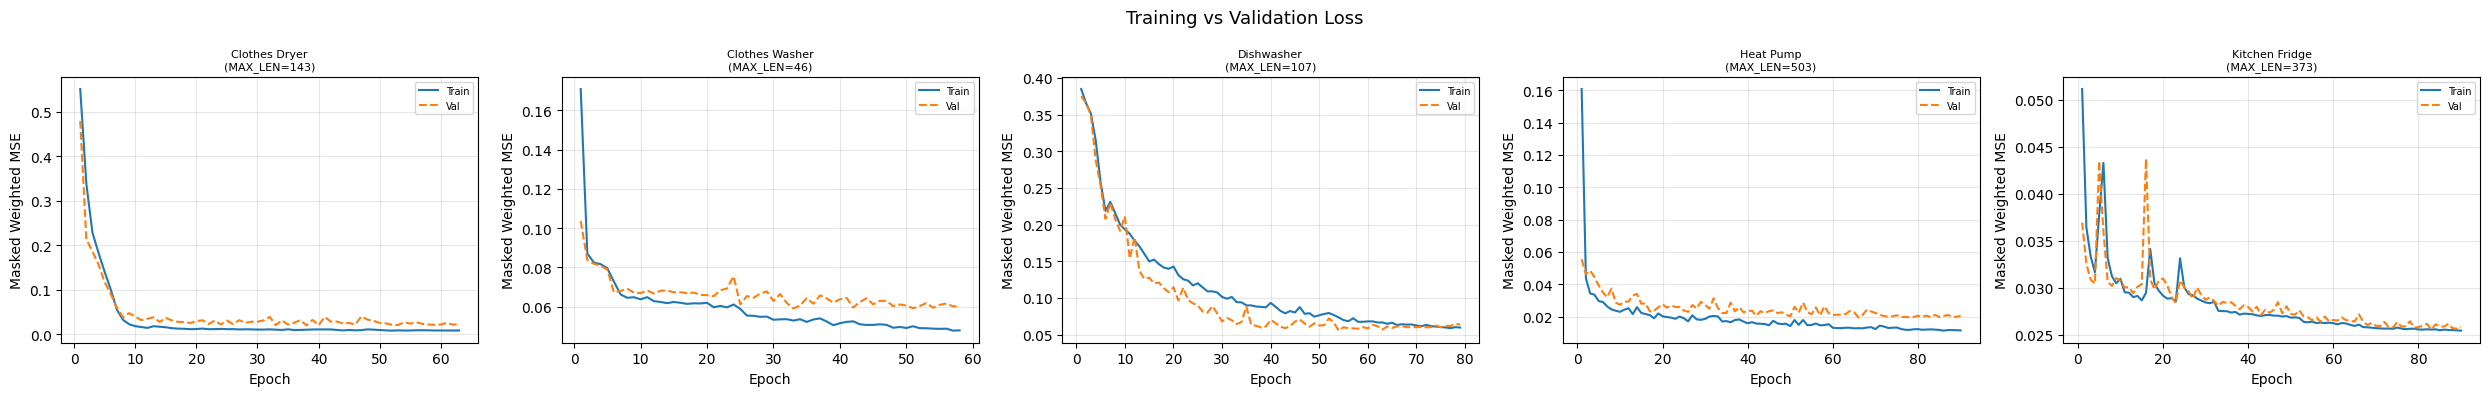

In [89]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (app, res) in zip(axes, results.items()):
    h  = res['history']
    ep = range(1, len(h['train_loss']) + 1)
    ax.plot(ep, h['train_loss'], label='Train', linewidth=1.5)
    ax.plot(ep, h['val_loss'],   label='Val',   linewidth=1.5, linestyle='--')
    ax.set_title(f'{app}\n(MAX_LEN={res["max_len"]})', fontsize=8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Masked Weighted MSE')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Loss', fontsize=13)
plt.tight_layout()
plt.show()

## 11 · Event Sequence Visualisation

Shows predicted vs actual appliance power for individual test events.
Each subplot is one complete ON event with its leading/trailing context.

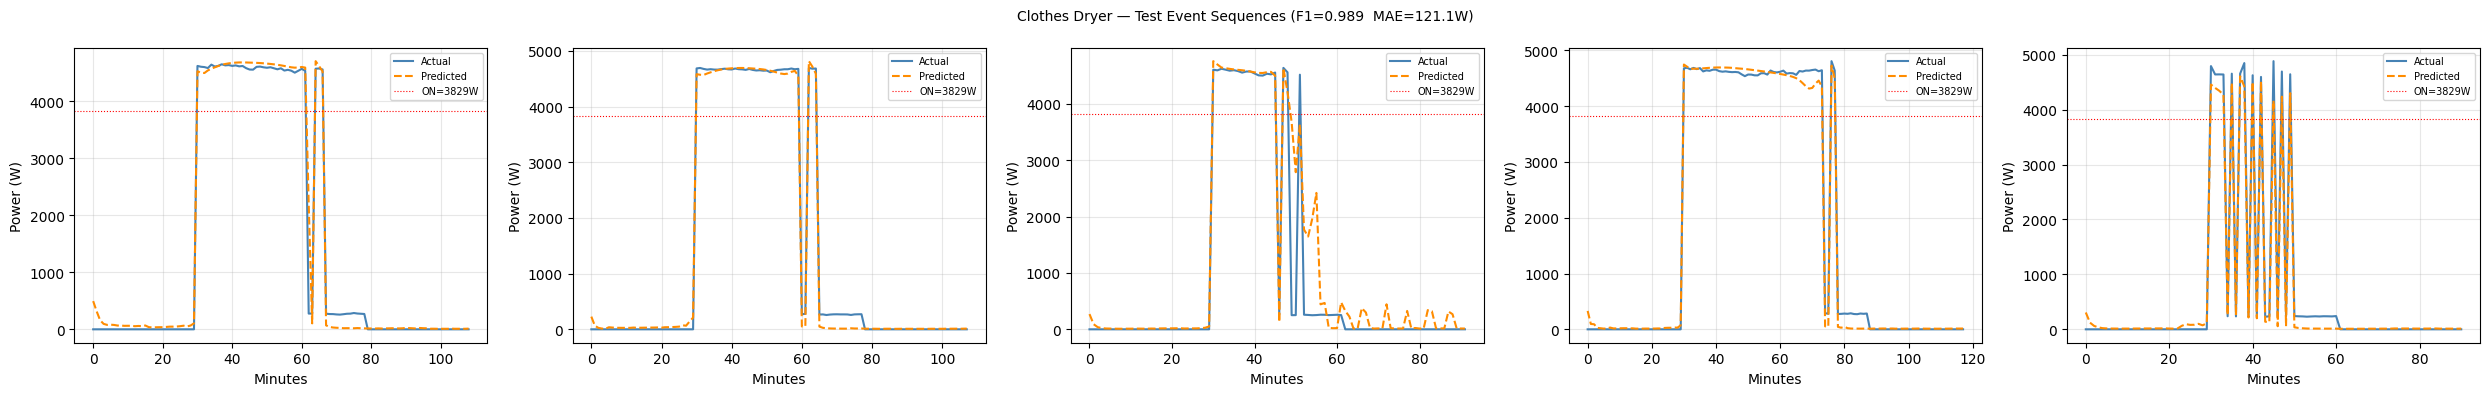

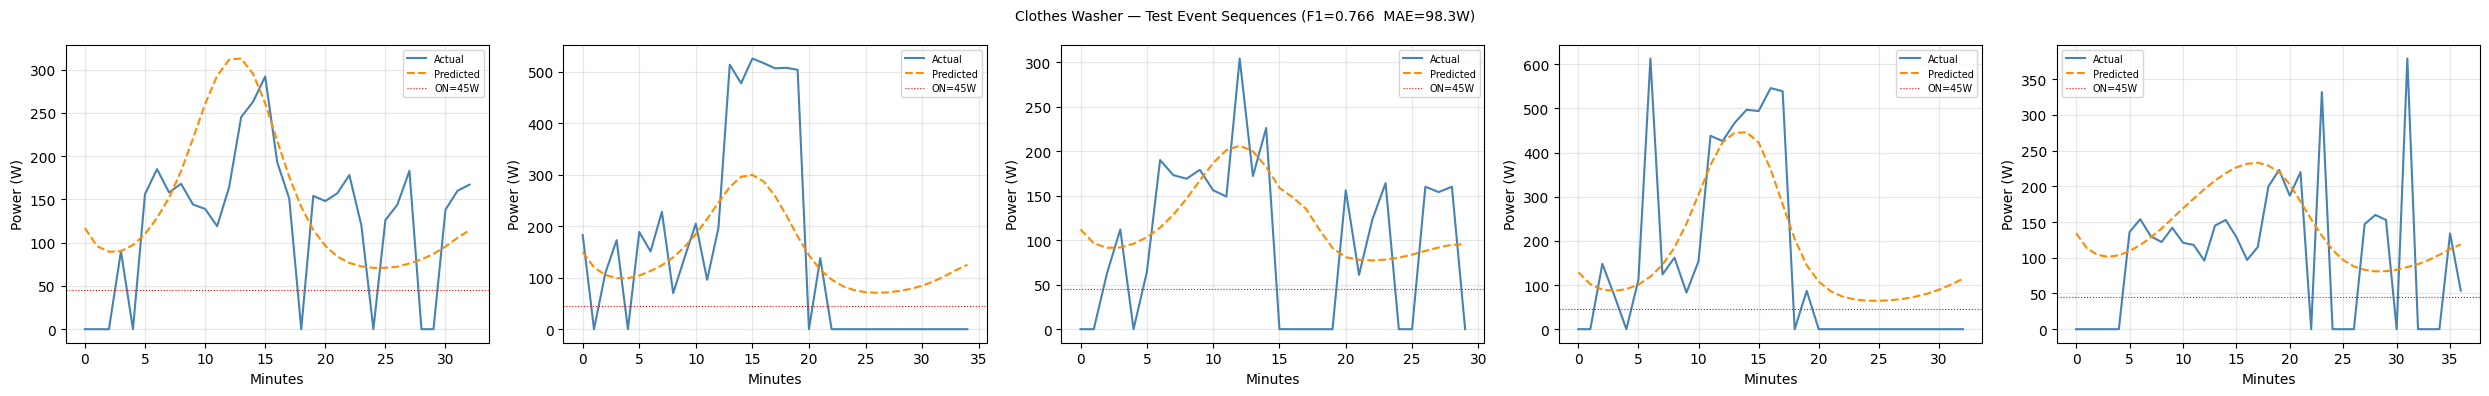

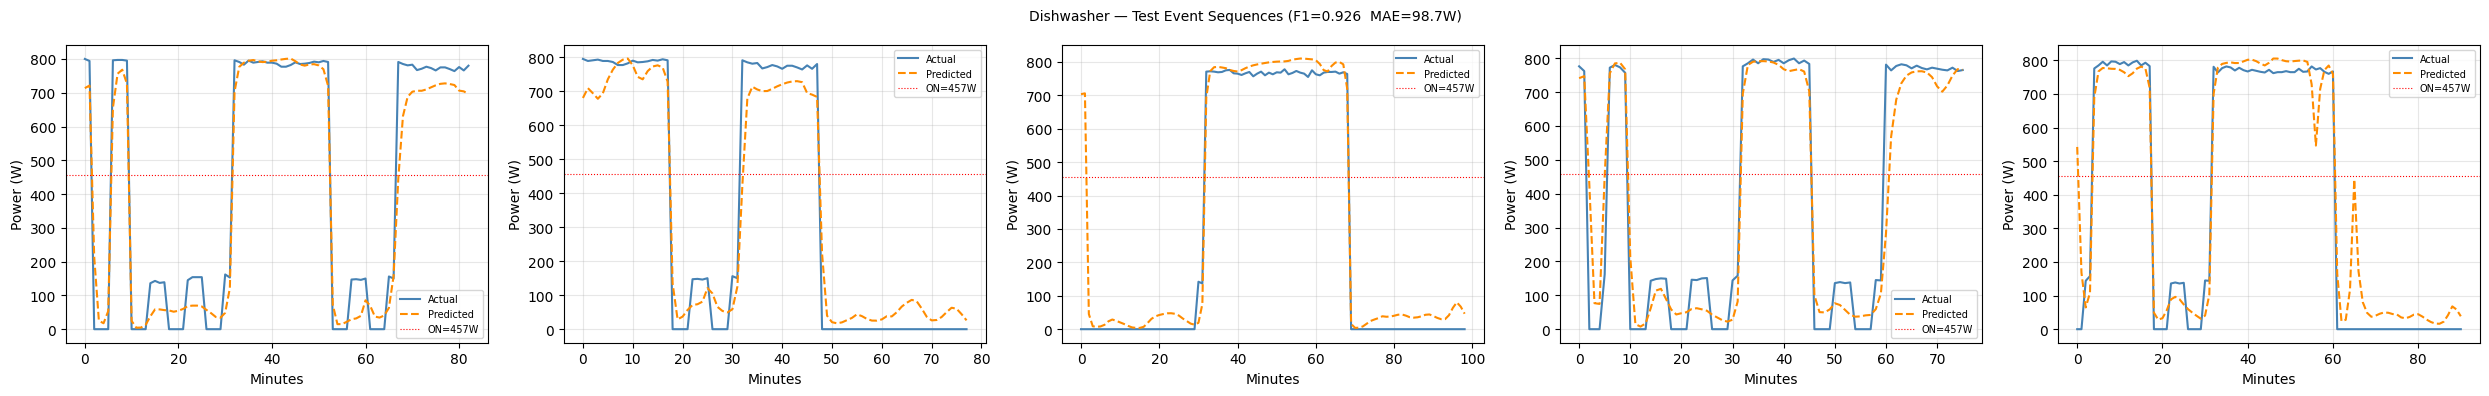

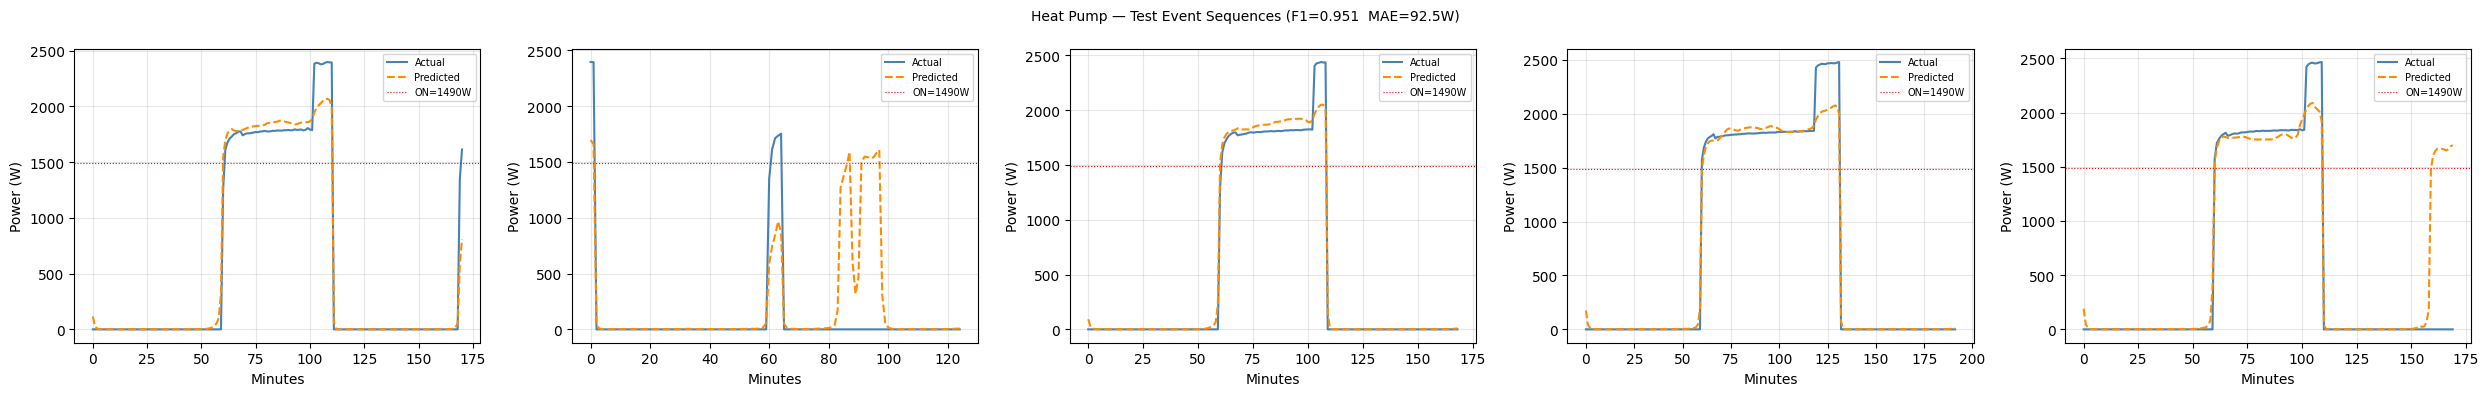

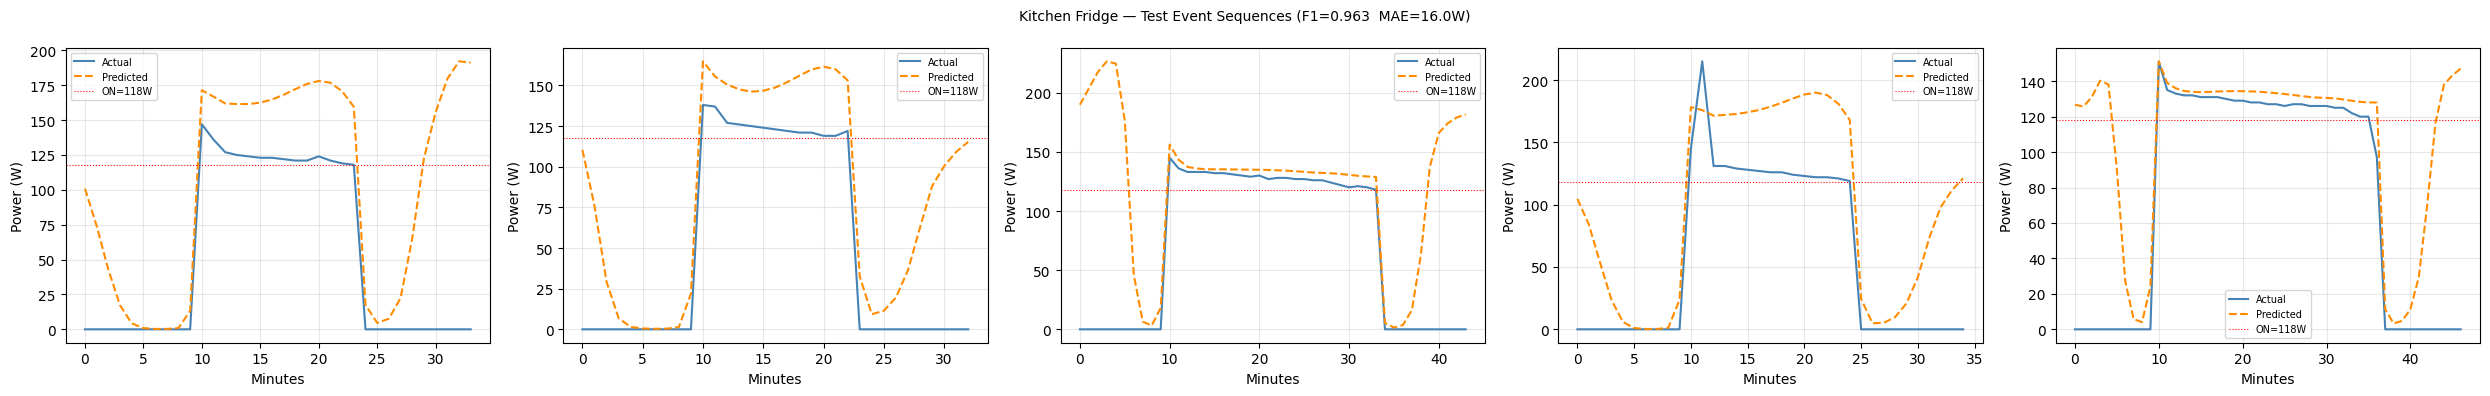

In [90]:
for app, res in results.items():
    pred_seqs = res['y_pred_seq']
    true_seqs = res['y_true_seq']

    if pred_seqs is None or len(pred_seqs) == 0:
        print(f'{app}: no test sequences to show')
        continue

    cap     = res['norm_cap']
    thr_w   = res['thr_watts']
    n_show  = len(pred_seqs)

    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4))
    if n_show == 1:
        axes = [axes]

    for ax, yp, yt in zip(axes, pred_seqs, true_seqs):
        t = np.arange(len(yp))
        ax.plot(t, yt * cap, label='Actual',    linewidth=1.5,
                color='steelblue')
        ax.plot(t, yp * cap, label='Predicted', linewidth=1.5,
                linestyle='--', color='darkorange')
        ax.axhline(thr_w, color='red', linewidth=0.8,
                   linestyle=':', label=f'ON={thr_w:.0f}W')
        ax.set_xlabel('Minutes')
        ax.set_ylabel('Power (W)')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f'{app} — Test Event Sequences '
        f'(F1={res["metrics"]["F1"]:.3f}  '
        f'MAE={res["metrics"]["MAE_W"]:.1f}W)',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

## 12 · F1, Precision, Recall Bar Charts

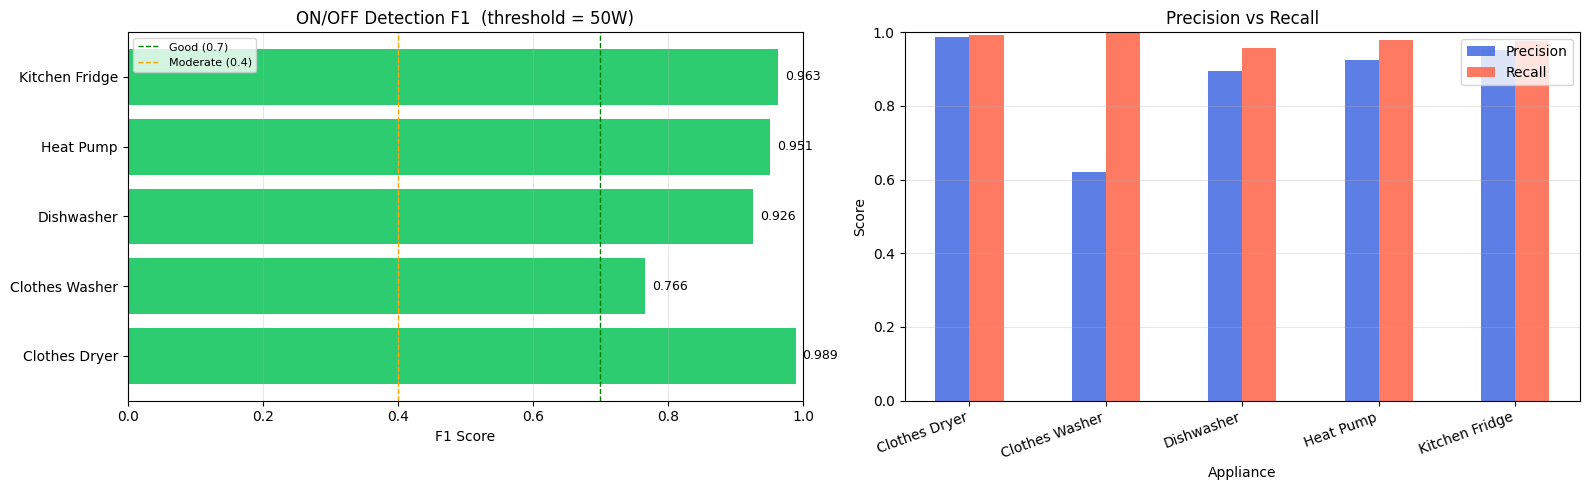

In [91]:
apps       = list(results.keys())
f1s        = [results[a]['metrics'].get('F1',        0) for a in apps]
precisions = [results[a]['metrics'].get('Precision', 0) for a in apps]
recalls    = [results[a]['metrics'].get('Recall',    0) for a in apps]

x     = np.arange(len(apps))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1 horizontal bars
colors = [
    '#2ecc71' if f >= 0.7 else
    '#e67e22' if f >= 0.4 else
    '#e74c3c'
    for f in f1s
]
bars = axes[0].barh(apps, f1s, color=colors)
axes[0].axvline(0.7, linestyle='--', color='green',  linewidth=1,
                label='Good (0.7)')
axes[0].axvline(0.4, linestyle='--', color='orange', linewidth=1,
                label='Moderate (0.4)')
axes[0].set_xlabel('F1 Score')
axes[0].set_title(
    f'ON/OFF Detection F1  (threshold = {WATTS_ON_THRESHOLD:.0f}W)'
)
axes[0].set_xlim(0, 1)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, f1s):
    if not math.isnan(val):
        axes[0].text(
            val + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9
        )

# Precision vs Recall
axes[1].bar(x - width / 2, precisions, width,
            label='Precision', color='royalblue', alpha=0.85)
axes[1].bar(x + width / 2, recalls,    width,
            label='Recall',    color='tomato',    alpha=0.85)
axes[1].set_xlabel('Appliance')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision vs Recall')
axes[1].set_xticks(x)
axes[1].set_xticklabels(apps, rotation=20, ha='right')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 13 · MAE & RMSE Bar Chart (Watts)

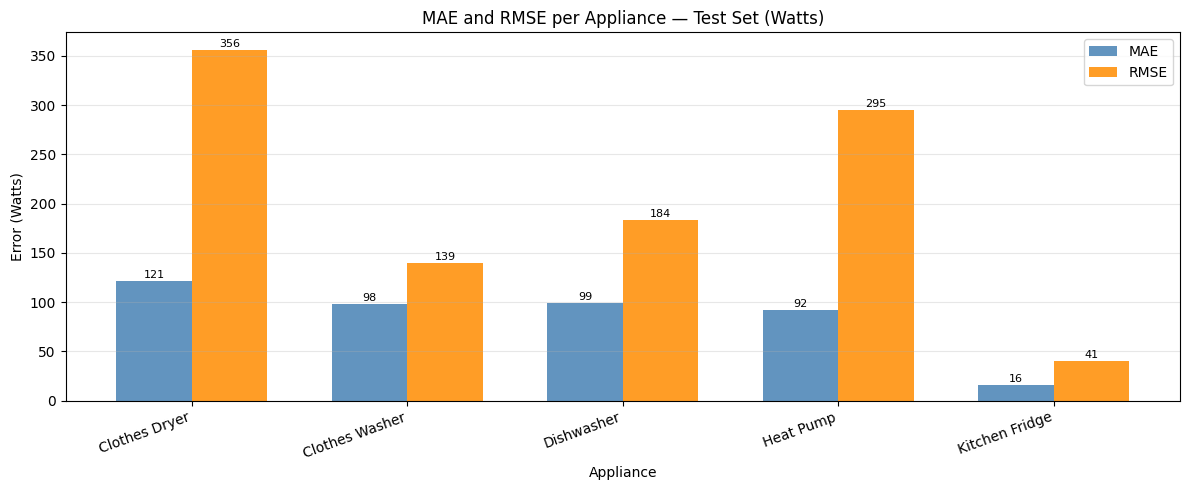

In [92]:
apps  = list(results.keys())
maes  = [results[a]['metrics'].get('MAE_W',  0) for a in apps]
rmses = [results[a]['metrics'].get('RMSE_W', 0) for a in apps]

x     = np.arange(len(apps))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width / 2, maes,  width,
            label='MAE',  color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width / 2, rmses, width,
            label='RMSE', color='darkorange', alpha=0.85)

ax.set_xlabel('Appliance')
ax.set_ylabel('Error (Watts)')
ax.set_title('MAE and RMSE per Appliance — Test Set (Watts)')
ax.set_xticks(x)
ax.set_xticklabels(apps, rotation=20, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    if not math.isnan(h):
        ax.text(
            bar.get_x() + bar.get_width() / 2, h + 1,
            f'{h:.0f}', ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

## 14 · Scatter Plot — Predicted vs Actual (Watts, flattened)

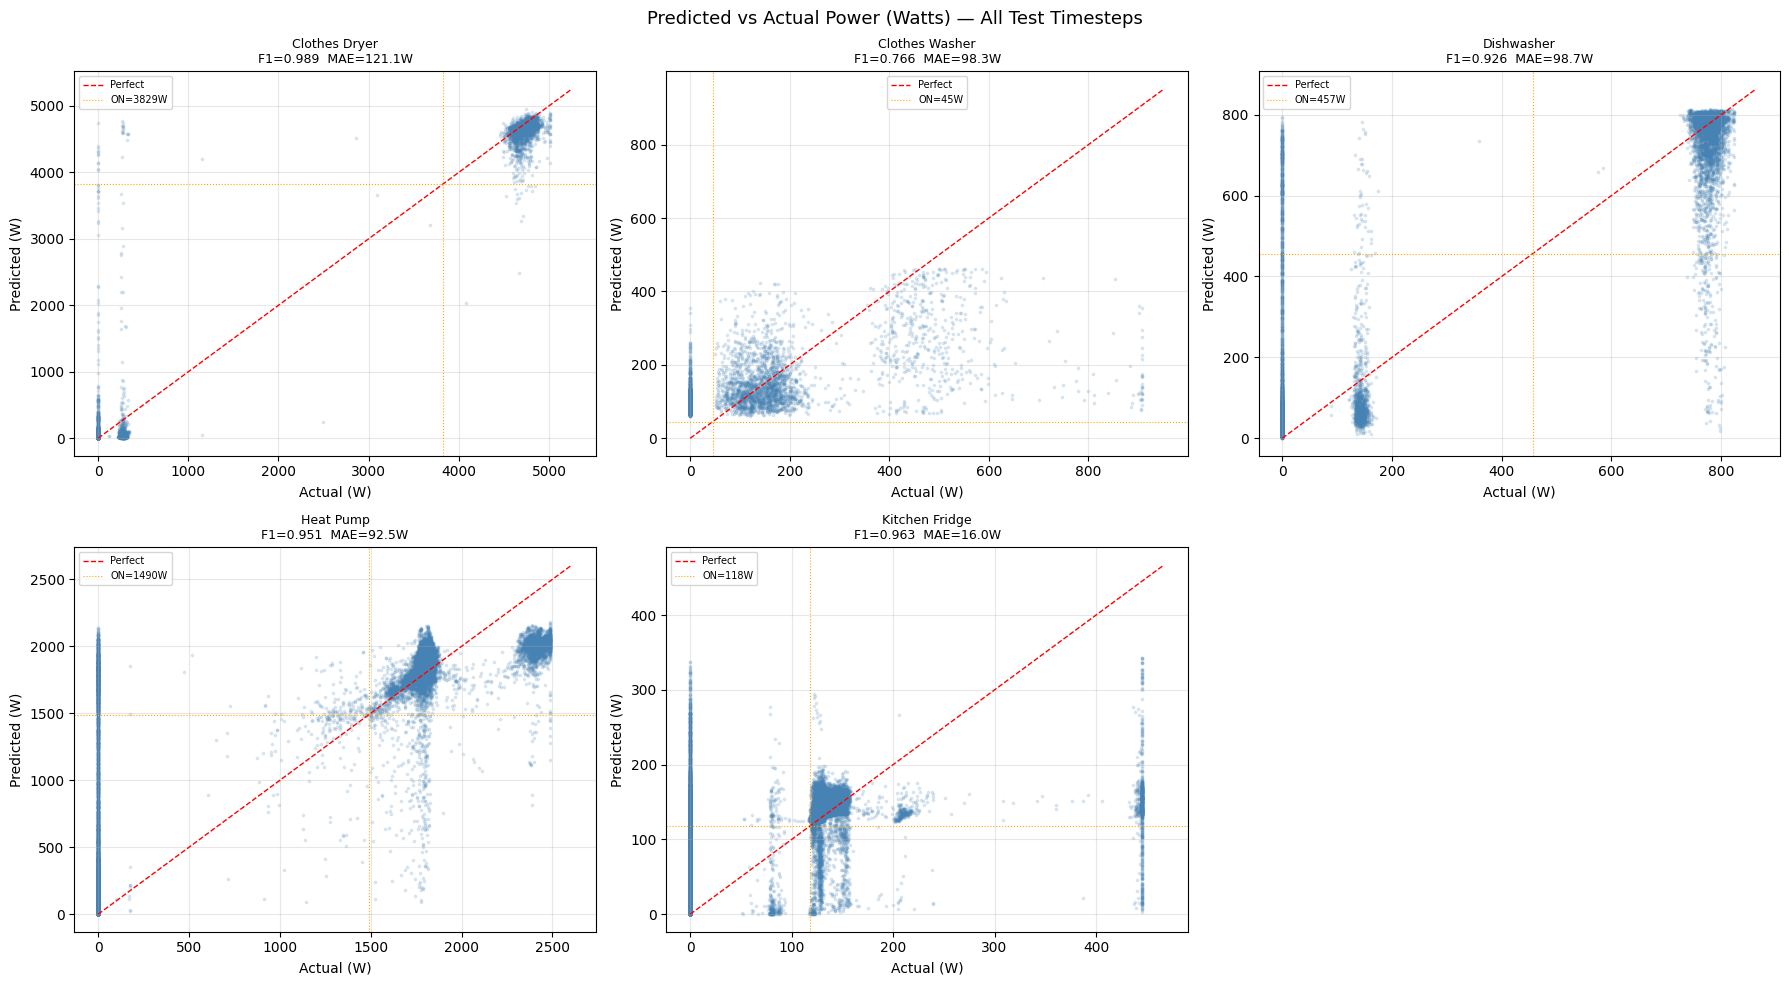

In [93]:
n = len(results)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for ax, (app, res) in zip(axes, results.items()):
    yp    = res['y_pred_flat']
    yt    = res['y_true_flat']
    cap   = res['norm_cap']
    thr_w = res['thr_watts']

    if len(yp) == 0:
        ax.set_title(f'{app}\nno test data')
        continue

    ax.scatter(yt * cap, yp * cap, alpha=0.15, s=3, color='steelblue')
    lim = max(float((yt * cap).max()), float((yp * cap).max())) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect')
    ax.axhline(thr_w, color='orange', linewidth=0.8, linestyle=':',
               label=f'ON={thr_w:.0f}W')
    ax.axvline(thr_w, color='orange', linewidth=0.8, linestyle=':')
    f1 = res['metrics'].get('F1', float('nan'))
    ax.set_title(
        f'{app}\nF1={f1:.3f}  MAE={res["metrics"]["MAE_W"]:.1f}W',
        fontsize=9
    )
    ax.set_xlabel('Actual (W)')
    ax.set_ylabel('Predicted (W)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Predicted vs Actual Power (Watts) — All Test Timesteps',
             fontsize=13)
plt.tight_layout()
plt.show()

## 15 · Residual Distribution

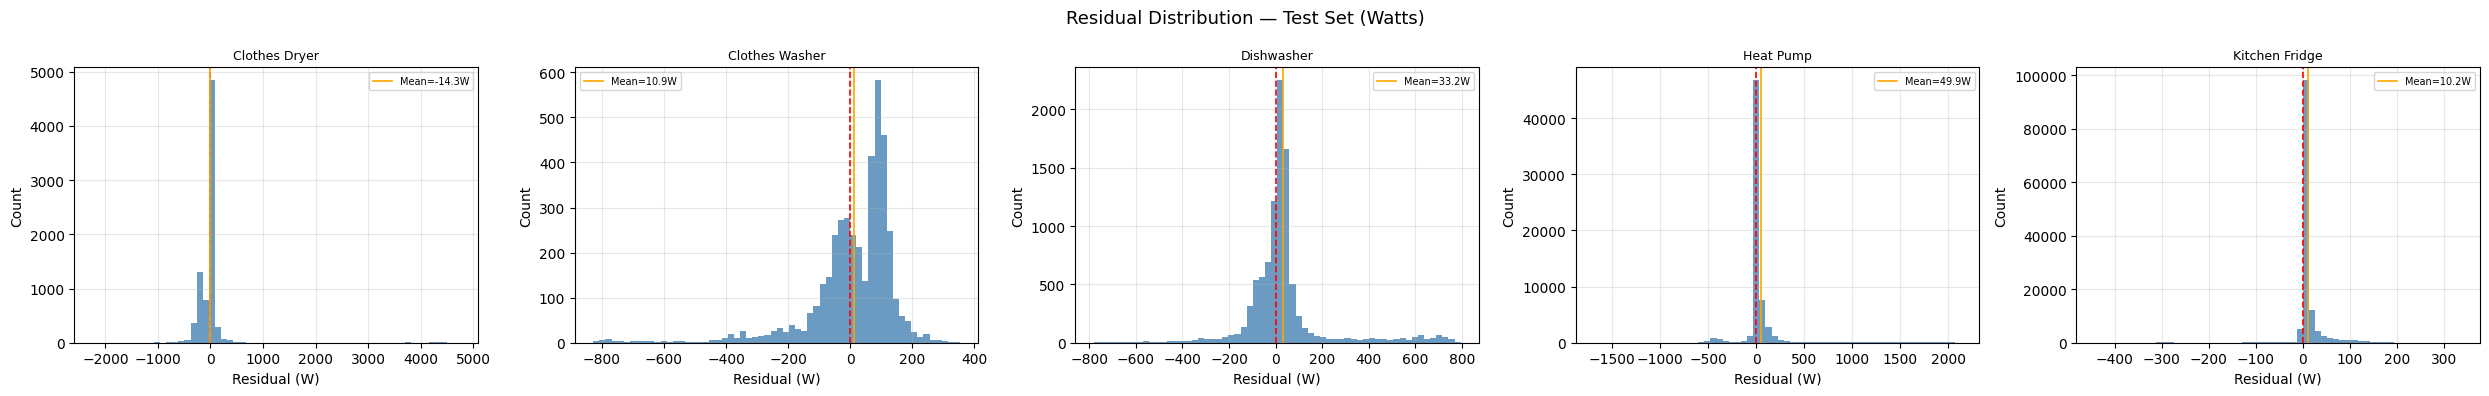

In [94]:
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
if n == 1:
    axes = [axes]

for ax, (app, res) in zip(axes, results.items()):
    yp  = res['y_pred_flat']
    yt  = res['y_true_flat']
    cap = res['norm_cap']

    if len(yp) == 0:
        ax.set_title(f'{app}\nno data')
        continue

    resid = (yp - yt) * cap
    ax.hist(resid, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(0,             color='red',    linewidth=1.2, linestyle='--')
    ax.axvline(resid.mean(),  color='orange', linewidth=1.2,
               label=f'Mean={resid.mean():.1f}W')
    ax.set_title(app, fontsize=9)
    ax.set_xlabel('Residual (W)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Residual Distribution — Test Set (Watts)', fontsize=13)
plt.tight_layout()
plt.show()